In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [31]:
# -----------------------------
# 1. Load annotated benchmark
# -----------------------------

csv_path = Path("../data/eval/labels_original_benchmark_50.csv")

df = pd.read_csv(csv_path)

df.head(15)

,timestamp,query_id,query,system,rank,chunk_id,doc_id,score,relevance,latency_ms
0,2026-04-24T14:32:49.724731,1,What is OPT?,dense,1,531,uni_028,NaN,1,53.02
1,2026-04-24T14:32:49.735853,1,What is OPT?,dense,2,530,uni_028,NaN,1,53.02
2,2026-04-24T14:32:49.748434,1,What is OPT?,dense,3,140,uni_001,NaN,1,53.02
3,2026-04-24T14:32:49.759526,1,What is OPT?,dense,4,259,uni_008,NaN,1,53.02
4,2026-04-24T14:32:49.763529,1,What is OPT?,dense,5,527,uni_028,NaN,1,53.02
5,2026-04-24T14:32:49.769424,1,What is OPT?,hybrid,1,541,uni_030,0.030777,1,511.00
6,2026-04-24T14:32:49.774472,1,What is OPT?,hybrid,2,542,uni_030,0.028439,1,511.00
7,2026-04-24T14:32:49.778535,1,What is OPT?,hybrid,3,31,gov_005,0.016393,3,511.00
8,2026-04-24T14:32:49.782464,1,What is OPT?,hybrid,4,531,uni_028,0.016393,1,511.00
9,2026-04-24T14:32:49.787420,1,What is OPT?,hybrid,5,44,gov_005,0.016129,2,511.00


In [5]:
# Basic overview

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

df.info()

Shape: (708, 10)
Columns: ['timestamp', 'query_id', 'query', 'system', 'rank', 'chunk_id', 'doc_id', 'score', 'relevance', 'latency_ms']
<class 'pandas.DataFrame'>
RangeIndex: 708 entries, 0 to 707
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   timestamp   708 non-null    str    
 1   query_id    708 non-null    int64  
 2   query       708 non-null    str    
 3   system      708 non-null    str    
 4   rank        708 non-null    int64  
 5   chunk_id    708 non-null    int64  
 6   doc_id      708 non-null    str    
 7   score       480 non-null    float64
 8   relevance   708 non-null    int64  
 9   latency_ms  708 non-null    float64
dtypes: float64(2), int64(4), str(4)
memory usage: 107.4 KB


In [6]:
# -----------------------------
# 2. Clean and validate data
# -----------------------------

df["system"] = df["system"].astype(str)
df["query_id"] = df["query_id"].astype(int)
df["rank"] = df["rank"].astype(int)
df["relevance"] = df["relevance"].fillna(0).astype(int)

systems = sorted(df["system"].unique())
query_ids = sorted(df["query_id"].unique())

print("Systems:", systems)
print("Number of queries:", len(query_ids))
print("Relevance labels:", sorted(df["relevance"].unique()))

Systems: ['dense', 'hybrid', 'hybrid_rerank']
Number of queries: 50
Relevance labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [7]:
# -----------------------------
# 3. Check missing retrieved results
# -----------------------------

expected_k = 5

count_table = (
    df.groupby(["query_id", "query", "system"])
      .size()
      .reset_index(name="retrieved_count")
)

count_table.head()

,query_id,query,system,retrieved_count
0,1,What is OPT?,dense,5
1,1,What is OPT?,hybrid,5
2,1,What is OPT?,hybrid_rerank,5
3,2,Who is eligible for OPT?,dense,5
4,2,Who is eligible for OPT?,hybrid,5


In [8]:
# Find query-system pairs with fewer than 5 results

missing_results = count_table[count_table["retrieved_count"] < expected_k]

missing_results.sort_values(["query_id", "system"])

,query_id,query,system,retrieved_count
39,14,How many unemployment days are allowed on OPT?,dense,1
40,14,How many unemployment days are allowed on OPT?,hybrid,1
41,14,How many unemployment days are allowed on OPT?,hybrid_rerank,1
57,20,Does my employer need E-Verify for STEM OPT?,hybrid,3
58,20,Does my employer need E-Verify for STEM OPT?,hybrid_rerank,3
83,29,Can I work off campus using CPT?,dense,3
92,32,Can CPT be part-time or full-time?,dense,1
113,39,What is cap-gap?,dense,2
143,49,opt no job what happen,dense,1
144,49,opt no job what happen,hybrid,1


In [9]:
# Show systems with zero results by completing the query-system grid

all_pairs = pd.MultiIndex.from_product(
    [query_ids, systems],
    names=["query_id", "system"]
).to_frame(index=False)

query_lookup = df[["query_id", "query"]].drop_duplicates()

complete_counts = (
    all_pairs
    .merge(query_lookup, on="query_id", how="left")
    .merge(count_table[["query_id", "system", "retrieved_count"]],
           on=["query_id", "system"], how="left")
)

complete_counts["retrieved_count"] = complete_counts["retrieved_count"].fillna(0).astype(int)

complete_counts[complete_counts["retrieved_count"] < expected_k].sort_values(
    ["query_id", "system"]
)

,query_id,system,query,retrieved_count
39,14,dense,How many unemployment days are allowed on OPT?,1
40,14,hybrid,How many unemployment days are allowed on OPT?,1
41,14,hybrid_rerank,How many unemployment days are allowed on OPT?,1
57,20,dense,Does my employer need E-Verify for STEM OPT?,0
58,20,hybrid,Does my employer need E-Verify for STEM OPT?,3
59,20,hybrid_rerank,Does my employer need E-Verify for STEM OPT?,3
84,29,dense,Can I work off campus using CPT?,3
93,32,dense,Can CPT be part-time or full-time?,1
114,39,dense,What is cap-gap?,2
144,49,dense,opt no job what happen,1


In [10]:
# -----------------------------
# 4. Define evaluation functions
# -----------------------------

def precision_at_k(group, k=5, threshold=1):
    """
    Precision@k:
    proportion of top-k retrieved chunks with relevance >= threshold.
    """
    topk = group.sort_values("rank").head(k)
    return (topk["relevance"] >= threshold).mean()


def hit_at_k(group, k=5, threshold=1):
    """
    Hit@k:
    whether at least one relevant chunk appears in top-k.
    """
    topk = group.sort_values("rank").head(k)
    return int((topk["relevance"] >= threshold).any())


def dcg_at_k(relevances, k=5):
    """
    Discounted Cumulative Gain.
    Uses graded relevance labels.
    """
    relevances = np.asarray(relevances)[:k]
    discounts = np.log2(np.arange(2, len(relevances) + 2))
    return np.sum((2 ** relevances - 1) / discounts)


def ndcg_at_k(group, k=5):
    """
    Normalized DCG@k.
    Compares actual ranking with ideal ranking.
    """
    ranked_rels = group.sort_values("rank")["relevance"].tolist()
    actual_dcg = dcg_at_k(ranked_rels, k)

    ideal_rels = sorted(ranked_rels, reverse=True)
    ideal_dcg = dcg_at_k(ideal_rels, k)

    if ideal_dcg == 0:
        return 0.0

    return actual_dcg / ideal_dcg


def mean_relevance_at_k(group, k=5):
    topk = group.sort_values("rank").head(k)
    return topk["relevance"].mean()


def total_relevance_at_k(group, k=5):
    topk = group.sort_values("rank").head(k)
    return topk["relevance"].sum()

In [11]:
# -----------------------------
# 5. Per-query system metrics
# -----------------------------

metrics = []

for (query_id, system), group in df.groupby(["query_id", "system"]):
    query_text = group["query"].iloc[0]

    metrics.append({
        "query_id": query_id,
        "query": query_text,
        "system": system,
        "retrieved_count": len(group),
        "p_at_1": precision_at_k(group, k=1, threshold=1),
        "p_at_3": precision_at_k(group, k=3, threshold=1),
        "p_at_5": precision_at_k(group, k=5, threshold=1),
        "strong_p_at_5": precision_at_k(group, k=5, threshold=2),
        "hit_at_5": hit_at_k(group, k=5, threshold=1),
        "ndcg_at_5": ndcg_at_k(group, k=5),
        "mean_relevance_at_5": mean_relevance_at_k(group, k=5),
        "total_relevance_at_5": total_relevance_at_k(group, k=5),
        "avg_latency_ms": group["latency_ms"].mean()
    })

metrics_df = pd.DataFrame(metrics)

metrics_df.head()

,query_id,query,system,retrieved_count,p_at_1,p_at_3,p_at_5,strong_p_at_5,hit_at_5,ndcg_at_5,mean_relevance_at_5,total_relevance_at_5,avg_latency_ms
0,1,What is OPT?,dense,5,1.0,1.000000,1.0,0.0,1,1.000000,1.0,5,53.02
1,1,What is OPT?,hybrid,5,1.0,1.000000,1.0,0.4,1,0.658370,1.6,8,511.00
2,1,What is OPT?,hybrid_rerank,5,1.0,1.000000,1.0,0.4,1,0.905645,1.8,9,817.47
3,2,Who is eligible for OPT?,dense,5,0.0,0.000000,0.4,0.0,1,0.501266,0.4,2,59.16
4,2,Who is eligible for OPT?,hybrid,5,1.0,0.666667,0.4,0.4,1,0.919721,1.2,6,394.42


In [12]:
# -----------------------------
# 6. Overall system comparison
# -----------------------------

overall = (
    metrics_df.groupby("system")
    .agg(
        queries=("query_id", "nunique"),
        avg_retrieved_count=("retrieved_count", "mean"),
        p_at_1=("p_at_1", "mean"),
        p_at_3=("p_at_3", "mean"),
        p_at_5=("p_at_5", "mean"),
        strong_p_at_5=("strong_p_at_5", "mean"),
        hit_at_5=("hit_at_5", "mean"),
        ndcg_at_5=("ndcg_at_5", "mean"),
        mean_relevance_at_5=("mean_relevance_at_5", "mean"),
        total_relevance_at_5=("total_relevance_at_5", "mean"),
        avg_latency_ms=("avg_latency_ms", "mean")
    )
    .reset_index()
)

overall

,system,queries,avg_retrieved_count,p_at_1,p_at_3,p_at_5,strong_p_at_5,hit_at_5,ndcg_at_5,mean_relevance_at_5,total_relevance_at_5,avg_latency_ms
0,dense,49,4.653061,0.44898,0.387755,0.342857,0.204082,0.653061,0.541918,0.689796,3.204082,65.368776
1,hybrid,50,4.800000,0.64000,0.606667,0.560000,0.408000,0.860000,0.705813,1.288000,6.080000,348.583600
2,hybrid_rerank,50,4.800000,0.76000,0.713333,0.676000,0.508000,0.860000,0.771541,1.588000,7.580000,633.149400


In [13]:
# Format for easier reading

overall_formatted = overall.copy()

percent_cols = ["p_at_1", "p_at_3", "p_at_5", "strong_p_at_5", "hit_at_5", "ndcg_at_5"]

for col in percent_cols:
    overall_formatted[col] = (overall_formatted[col] * 100).round(2)

overall_formatted["avg_latency_ms"] = overall_formatted["avg_latency_ms"].round(2)
overall_formatted["avg_retrieved_count"] = overall_formatted["avg_retrieved_count"].round(2)
overall_formatted["mean_relevance_at_5"] = overall_formatted["mean_relevance_at_5"].round(2)
overall_formatted["total_relevance_at_5"] = overall_formatted["total_relevance_at_5"].round(2)

overall_formatted

,system,queries,avg_retrieved_count,p_at_1,p_at_3,p_at_5,strong_p_at_5,hit_at_5,ndcg_at_5,mean_relevance_at_5,total_relevance_at_5,avg_latency_ms
0,dense,49,4.65,44.9,38.78,34.29,20.41,65.31,54.19,0.69,3.20,65.37
1,hybrid,50,4.80,64.0,60.67,56.00,40.80,86.00,70.58,1.29,6.08,348.58
2,hybrid_rerank,50,4.80,76.0,71.33,67.60,50.80,86.00,77.15,1.59,7.58,633.15


In [14]:
# -----------------------------
# 7. Winner by query
# -----------------------------

winner_metric = "total_relevance_at_5"

pivot_scores = metrics_df.pivot_table(
    index=["query_id", "query"],
    columns="system",
    values=winner_metric
).reset_index()

pivot_scores.head()

system,query_id,query,dense,hybrid,hybrid_rerank
0,1,What is OPT?,5.0,8.0,9.0
1,2,Who is eligible for OPT?,2.0,6.0,4.0
2,3,How many months of OPT can I get?,1.0,1.0,3.0
3,4,Can I apply for OPT before graduation?,4.0,11.0,13.0
4,5,Can I apply for OPT after graduation?,3.0,9.0,12.0


In [15]:
def determine_winner(row, system_cols):
    scores = row[system_cols]
    max_score = scores.max()
    winners = scores[scores == max_score].index.tolist()

    if len(winners) == 1:
        return winners[0]
    else:
        return "tie"

system_cols = [col for col in pivot_scores.columns if col not in ["query_id", "query"]]

pivot_scores["winner"] = pivot_scores.apply(
    lambda row: determine_winner(row, system_cols),
    axis=1
)

winner_counts = pivot_scores["winner"].value_counts().reset_index()
winner_counts.columns = ["winner", "num_queries"]

winner_counts

,winner,num_queries
0,hybrid_rerank,26
1,tie,17
2,hybrid,6
3,dense,1


In [16]:
# Query-level winner table

pivot_scores.sort_values("query_id").head(20)

system,query_id,query,dense,hybrid,hybrid_rerank,winner
0,1,What is OPT?,5.0,8.0,9.0,hybrid_rerank
1,2,Who is eligible for OPT?,2.0,6.0,4.0,hybrid
2,3,How many months of OPT can I get?,1.0,1.0,3.0,hybrid_rerank
3,4,Can I apply for OPT before graduation?,4.0,11.0,13.0,hybrid_rerank
4,5,Can I apply for OPT after graduation?,3.0,9.0,12.0,hybrid_rerank
5,6,When should I apply for post-completion OPT?,13.0,7.0,12.0,dense
6,7,How long does OPT approval usually take?,3.0,3.0,4.0,hybrid_rerank
7,8,Do I need a job offer before applying for OPT?,6.0,10.0,13.0,hybrid_rerank
8,9,Can I work while my OPT application is pending?,9.0,12.0,4.0,hybrid
9,10,Can I travel while OPT is pending?,1.0,9.0,15.0,hybrid_rerank


In [17]:
# -----------------------------
# 8. Label distribution by system
# -----------------------------

label_dist = (
    df.groupby(["system", "relevance"])
      .size()
      .reset_index(name="count")
)

label_dist

,system,relevance,count
0,dense,0,148
1,dense,1,34
2,dense,2,15
3,dense,3,31
4,hybrid,0,106
5,hybrid,1,38
6,hybrid,2,22
7,hybrid,3,74
8,hybrid_rerank,0,77
9,hybrid_rerank,1,42


In [18]:
label_pivot = label_dist.pivot(
    index="relevance",
    columns="system",
    values="count"
).fillna(0).astype(int)

label_pivot

system,dense,hybrid,hybrid_rerank
relevance,,,
0,148,106,77
1,34,38,42
2,15,22,26
3,31,74,95


In [19]:
# -----------------------------
# 9. Rank-level relevance analysis
# -----------------------------

rank_relevance = (
    df.groupby(["system", "rank"])
      .agg(
          mean_relevance=("relevance", "mean"),
          relevant_rate=("relevance", lambda x: (x >= 1).mean()),
          strong_relevant_rate=("relevance", lambda x: (x >= 2).mean())
      )
      .reset_index()
)

rank_relevance

,system,rank,mean_relevance,relevant_rate,strong_relevant_rate
0,dense,1,0.959184,0.448980,0.265306
1,dense,2,0.739130,0.391304,0.217391
2,dense,3,0.666667,0.333333,0.200000
3,dense,4,0.431818,0.250000,0.136364
4,dense,5,0.613636,0.318182,0.181818
5,hybrid,1,1.660000,0.640000,0.540000
6,hybrid,2,1.104167,0.520833,0.291667
7,hybrid,3,1.541667,0.666667,0.520833
8,hybrid,4,0.829787,0.382979,0.255319
9,hybrid,5,1.170213,0.574468,0.382979


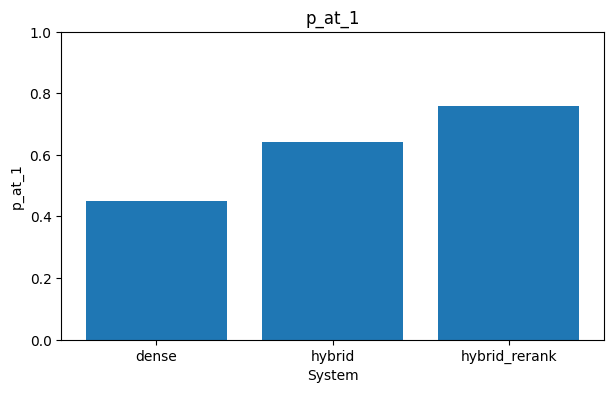

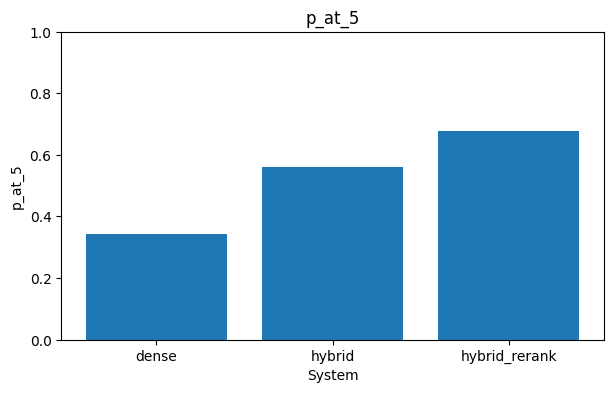

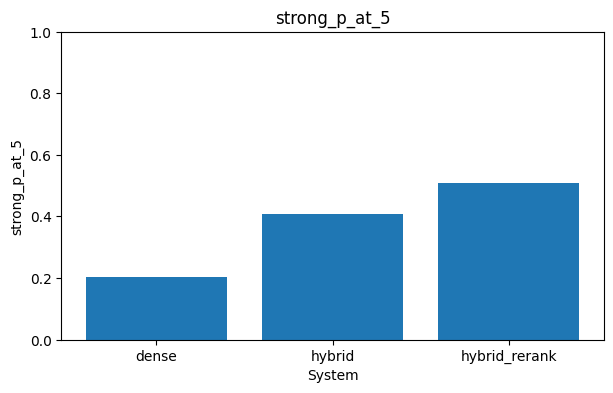

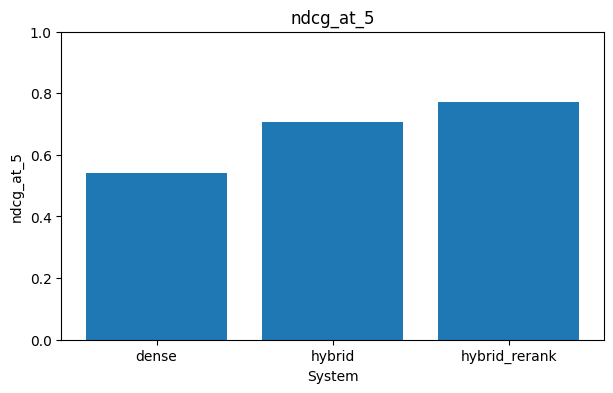

In [20]:
# -----------------------------
# 10. Plot overall metrics
# -----------------------------

plot_metrics = ["p_at_1", "p_at_5", "strong_p_at_5", "ndcg_at_5"]

for metric in plot_metrics:
    plt.figure(figsize=(7, 4))
    plt.bar(overall["system"], overall[metric])
    plt.title(metric)
    plt.ylabel(metric)
    plt.xlabel("System")
    plt.ylim(0, 1)
    plt.show()

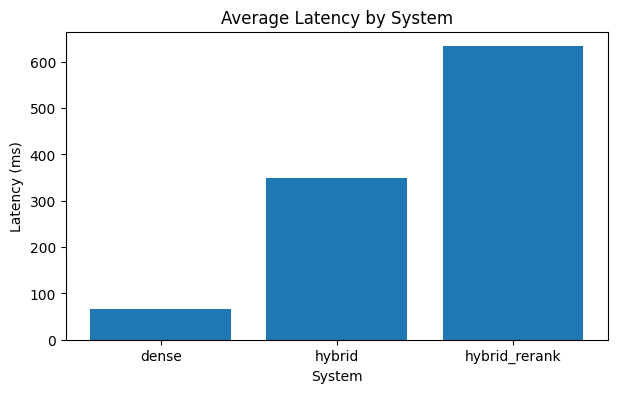

In [21]:
# Plot average latency

plt.figure(figsize=(7, 4))
plt.bar(overall["system"], overall["avg_latency_ms"])
plt.title("Average Latency by System")
plt.ylabel("Latency (ms)")
plt.xlabel("System")
plt.show()

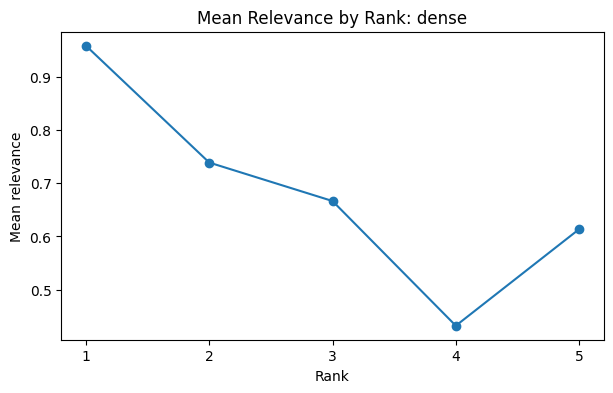

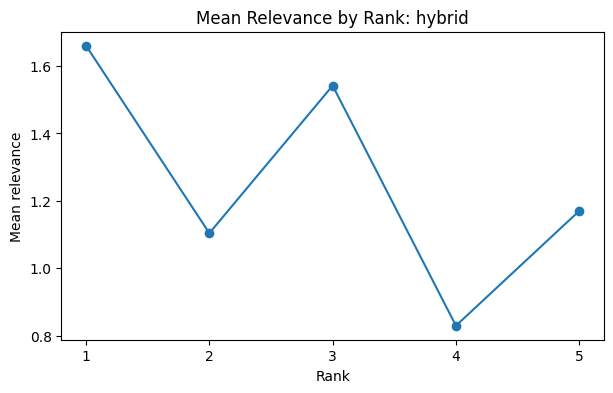

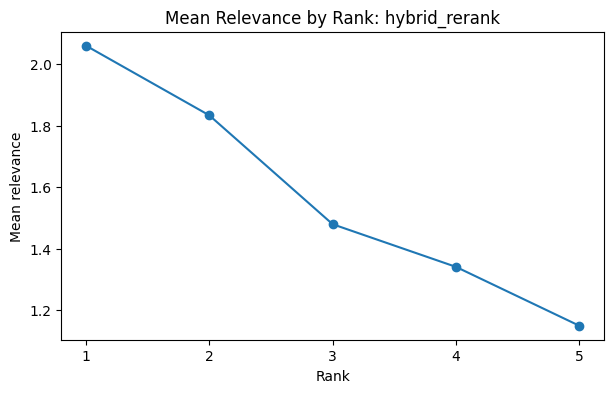

In [22]:
# Plot rank-level mean relevance

for system in systems:
    subset = rank_relevance[rank_relevance["system"] == system]

    plt.figure(figsize=(7, 4))
    plt.plot(subset["rank"], subset["mean_relevance"], marker="o")
    plt.title(f"Mean Relevance by Rank: {system}")
    plt.xlabel("Rank")
    plt.ylabel("Mean relevance")
    plt.xticks([1, 2, 3, 4, 5])
    plt.show()

In [23]:
# -----------------------------
# 11. Error analysis
# -----------------------------

# Queries where dense performs poorly but hybrid_rerank performs well

comparison = metrics_df.pivot_table(
    index=["query_id", "query"],
    columns="system",
    values="total_relevance_at_5"
).reset_index()

comparison["hybrid_rerank_gain_over_dense"] = (
    comparison.get("hybrid_rerank", 0) - comparison.get("dense", 0)
)

comparison.sort_values("hybrid_rerank_gain_over_dense", ascending=False).head(10)

system,query_id,query,dense,hybrid,hybrid_rerank,hybrid_rerank_gain_over_dense
12,13,Can I change employers while on OPT?,0.0,9.0,15.0,15.0
9,10,Can I travel while OPT is pending?,1.0,9.0,15.0,14.0
38,39,What is cap-gap?,0.0,6.0,14.0,14.0
26,27,Who is eligible for CPT?,1.0,6.0,12.0,11.0
44,45,What documents do I need to re-enter on OPT?,0.0,7.0,11.0,11.0
46,47,Do I need a travel signature while on OPT?,1.0,8.0,12.0,11.0
32,33,Can I start working before CPT is approved?,0.0,6.0,10.0,10.0
31,32,Can CPT be part-time or full-time?,0.0,10.0,10.0,10.0
4,5,Can I apply for OPT after graduation?,3.0,9.0,12.0,9.0
3,4,Can I apply for OPT before graduation?,4.0,11.0,13.0,9.0


In [24]:
# Queries where reranking improves over hybrid

comparison["rerank_gain_over_hybrid"] = (
    comparison.get("hybrid_rerank", 0) - comparison.get("hybrid", 0)
)

comparison.sort_values("rerank_gain_over_hybrid", ascending=False).head(10)

system,query_id,query,dense,hybrid,hybrid_rerank,hybrid_rerank_gain_over_dense,rerank_gain_over_hybrid
38,39,What is cap-gap?,0.0,6.0,14.0,14.0,8.0
12,13,Can I change employers while on OPT?,0.0,9.0,15.0,15.0,6.0
20,21,What is Form I-983?,0.0,3.0,9.0,9.0,6.0
26,27,Who is eligible for CPT?,1.0,6.0,12.0,11.0,6.0
9,10,Can I travel while OPT is pending?,1.0,9.0,15.0,14.0,6.0
5,6,When should I apply for post-completion OPT?,13.0,7.0,12.0,-1.0,5.0
32,33,Can I start working before CPT is approved?,0.0,6.0,10.0,10.0,4.0
11,12,When can I start working on OPT?,3.0,1.0,5.0,2.0,4.0
44,45,What documents do I need to re-enter on OPT?,0.0,7.0,11.0,11.0,4.0
43,44,Can I travel outside the US while on OPT?,9.0,9.0,13.0,4.0,4.0


In [25]:
# Queries where reranking hurts compared with hybrid

comparison.sort_values("rerank_gain_over_hybrid", ascending=True).head(10)

system,query_id,query,dense,hybrid,hybrid_rerank,hybrid_rerank_gain_over_dense,rerank_gain_over_hybrid
8,9,Can I work while my OPT application is pending?,9.0,12.0,4.0,-5.0,-8.0
1,2,Who is eligible for OPT?,2.0,6.0,4.0,2.0,-2.0
30,31,What is the difference between CPT and OPT?,2.0,3.0,1.0,-1.0,-2.0
16,17,Who qualifies for STEM OPT extension?,13.0,15.0,13.0,0.0,-2.0
33,34,Can I do CPT during summer break?,9.0,10.0,8.0,-1.0,-2.0
23,24,Can I travel while STEM OPT is pending?,7.0,10.0,9.0,2.0,-1.0
13,14,How many unemployment days are allowed on OPT?,3.0,3.0,3.0,0.0,0.0
19,20,Does my employer need E-Verify for STEM OPT?,NaN,9.0,9.0,NaN,0.0
18,19,When should I apply for STEM OPT?,3.0,10.0,10.0,7.0,0.0
24,25,Can remote work qualify for STEM OPT?,2.0,2.0,2.0,0.0,0.0


In [26]:
# -----------------------------
# 12. Inspect specific query results
# -----------------------------

def inspect_query(query_id):
    subset = df[df["query_id"] == query_id].sort_values(["system", "rank"])

    display_cols = [
        "query_id", "query", "system", "rank",
        "chunk_id", "doc_id", "score",
        "relevance", "latency_ms"
    ]

    return subset[display_cols]

inspect_query(1)

,query_id,query,system,rank,chunk_id,doc_id,score,relevance,latency_ms
0,1,What is OPT?,dense,1,531,uni_028,NaN,1,53.02
1,1,What is OPT?,dense,2,530,uni_028,NaN,1,53.02
2,1,What is OPT?,dense,3,140,uni_001,NaN,1,53.02
3,1,What is OPT?,dense,4,259,uni_008,NaN,1,53.02
4,1,What is OPT?,dense,5,527,uni_028,NaN,1,53.02
5,1,What is OPT?,hybrid,1,541,uni_030,0.030777,1,511.00
6,1,What is OPT?,hybrid,2,542,uni_030,0.028439,1,511.00
7,1,What is OPT?,hybrid,3,31,gov_005,0.016393,3,511.00
8,1,What is OPT?,hybrid,4,531,uni_028,0.016393,1,511.00
9,1,What is OPT?,hybrid,5,44,gov_005,0.016129,2,511.00


In [27]:
# Example: inspect worst dense failures

dense_failures = comparison.sort_values(
    "hybrid_rerank_gain_over_dense",
    ascending=False
).head(5)

dense_failures[["query_id", "query", "dense", "hybrid", "hybrid_rerank"]]

system,query_id,query,dense,hybrid,hybrid_rerank
12,13,Can I change employers while on OPT?,0.0,9.0,15.0
9,10,Can I travel while OPT is pending?,1.0,9.0,15.0
38,39,What is cap-gap?,0.0,6.0,14.0
26,27,Who is eligible for CPT?,1.0,6.0,12.0
44,45,What documents do I need to re-enter on OPT?,0.0,7.0,11.0


In [28]:
# Change the query_id here to inspect manually

inspect_query(query_id=1)

,query_id,query,system,rank,chunk_id,doc_id,score,relevance,latency_ms
0,1,What is OPT?,dense,1,531,uni_028,NaN,1,53.02
1,1,What is OPT?,dense,2,530,uni_028,NaN,1,53.02
2,1,What is OPT?,dense,3,140,uni_001,NaN,1,53.02
3,1,What is OPT?,dense,4,259,uni_008,NaN,1,53.02
4,1,What is OPT?,dense,5,527,uni_028,NaN,1,53.02
5,1,What is OPT?,hybrid,1,541,uni_030,0.030777,1,511.00
6,1,What is OPT?,hybrid,2,542,uni_030,0.028439,1,511.00
7,1,What is OPT?,hybrid,3,31,gov_005,0.016393,3,511.00
8,1,What is OPT?,hybrid,4,531,uni_028,0.016393,1,511.00
9,1,What is OPT?,hybrid,5,44,gov_005,0.016129,2,511.00


In [29]:
# # -----------------------------
# # 13. Export results
# # -----------------------------

# output_dir = Path("benchmark_analysis_outputs")
# output_dir.mkdir(exist_ok=True)

# overall.to_csv(output_dir / "overall_metrics.csv", index=False)
# metrics_df.to_csv(output_dir / "per_query_metrics.csv", index=False)
# comparison.to_csv(output_dir / "system_comparison_by_query.csv", index=False)
# missing_results.to_csv(output_dir / "missing_results.csv", index=False)
# rank_relevance.to_csv(output_dir / "rank_relevance_analysis.csv", index=False)

# print("Exported analysis files to:", output_dir)

In [30]:
# -----------------------------
# 14. Short written summary generator
# -----------------------------

best_p5 = overall.sort_values("p_at_5", ascending=False).iloc[0]
best_ndcg = overall.sort_values("ndcg_at_5", ascending=False).iloc[0]
fastest = overall.sort_values("avg_latency_ms", ascending=True).iloc[0]

summary = f"""
Retrieval Benchmark Summary

The benchmark contains {df['query_id'].nunique()} queries and {len(df)} judged retrieved chunks.

Best Precision@5:
- {best_p5['system']} with P@5 = {best_p5['p_at_5']:.3f}

Best nDCG@5:
- {best_ndcg['system']} with nDCG@5 = {best_ndcg['ndcg_at_5']:.3f}

Fastest system:
- {fastest['system']} with average latency = {fastest['avg_latency_ms']:.2f} ms

Overall interpretation:
Dense retrieval is the fastest method, but hybrid retrieval improves relevance substantially.
Hybrid + rerank usually provides the best ranking quality, especially for top-ranked results,
although it introduces additional latency.
"""

print(summary)


Retrieval Benchmark Summary

The benchmark contains 50 queries and 708 judged retrieved chunks.

Best Precision@5:
- hybrid_rerank with P@5 = 0.676

Best nDCG@5:
- hybrid_rerank with nDCG@5 = 0.772

Fastest system:
- dense with average latency = 65.37 ms

Overall interpretation:
Dense retrieval is the fastest method, but hybrid retrieval improves relevance substantially.
Hybrid + rerank usually provides the best ranking quality, especially for top-ranked results,
although it introduces additional latency.

